# Частинка у магнітному полі

### 1. Перший закон Ньютона 
$\dot{\vec{v}}=\dfrac{e}{m}\left[\vec{E} + [\vec{v}\times\vec{B}]\right]$

### 2. Усі операції лінійні:
$\dot{\vec{v_\perp}}=\dfrac{e}{m}\left[\vec{E_\perp} + [\vec{v_\perp}\times\vec{B}]\right]$

$\dot{\vec{v_\parallel}}=\dfrac{e}{m}\left[\vec{E_\parallel} + [\vec{v_\parallel}\times\vec{B}]\right]$

### 3. Вибір системи координат
$\dot{\vec{v}}_{\perp}=\dfrac{e}{m}\left[\vec{E_\perp} + \begin{pmatrix}
0 & B \\
-B & 0
\end{pmatrix}\vec{v_\perp}\right]$

$\dot{\vec{v_\parallel}}=\dfrac{e}{m}\vec{E_z}$





### 4. Розв'язок дифрівняння і деякі шененіганси з ним
$A(\phi) = \begin{pmatrix}
\cos{\phi} & \sin{\phi} \\
-\sin{\phi} & \cos{\phi}
\end{pmatrix}$

$\varphi = -\omega t - \dfrac{\pi}{2}$

$\omega = \dfrac{e}{m}B$

$V = \dfrac{1}{B}\begin{pmatrix}
E_y \\
-E_x 
\end{pmatrix}$



#### Фінальне рівняння
$r_{xy} = \dfrac{1}{\omega}rotation_\varphi(v_{0\perp} - V) + V t$


$z = v_{0z} t  + \dfrac{e}{2m}E_z t^2$

$\mathbf{v} = v_{0\perp} - V$

Матричний підхід

$(x,y) = \dfrac{1}{\omega}A(\varphi)\mathbf{v} + V t$

Формула родрігеса


$\mathbf{v}_{rot} = \mathbf{v} \cos\varphi + (\mathbf{k} \times \mathbf{v})\sin\varphi + \mathbf{k} (\mathbf{k} \cdot \mathbf{v}) (1 - \cos\varphi)$

$(x,y) = \dfrac{1}{\omega}\mathbf{v}_{rot} + V t$

Кватерніони

$(x,y) = K(t)(v_{0\perp} - V) + V t$
 

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

Початкові умови

In [2]:
e = 1
m = 10
Ex, Ey, Ez = 1, 1, 10
B = 4
vox, voy, voz = 2, 0, -40

Допоміжні функції та змінні

In [3]:
omega = e / m * B
vop = np.array([vox, voy])
V = np.array([Ey, -Ex]) / B
def phi(t):
    return -omega * t - np.pi / 2

In [4]:
def A(phi):
    return np.array([
        [np.cos(phi), np.sin(phi)],
        [-np.sin(phi), np.cos(phi)]])


Матричний підхід

In [5]:
def rotation(v, t):
    return A(phi(t)) @ v 


Формула Родрігеса

In [6]:
def rotation(v, t):
    v = np.array([*v, 0])
    p = -phi(t)
    k = np.array([0,0,1])
    v = v * np.cos(p) + np.cross(k, v) * np.sin(p) + k * np.dot(k, v) * (1 - np.cos(p))
    return np.array(v[:-1])

Кватерніони

In [7]:
def quaternion_multiply(q1, q2):
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])

def quaternion_rotation(v, t):
    p = -phi(t) / 2  
    k = np.array([0, 0, 1])
    q = np.array([np.cos(p), *(np.sin(p) * k)])
    q_conj = np.array([q[0], -q[1], -q[2], -q[3]])
    v_quat = np.array([0, *v])
    rotated = quaternion_multiply(quaternion_multiply(q, v_quat), q_conj)
    return rotated[1:]  

Функція радіус-вектора

In [8]:
def rp(t):
    return 1 / omega * rotation(vop - V, t) + V*t

def z(t):
    return voz * t + e / 2 / m * Ez *  t**2

def r(t):
    return np.array([*rp(t), z(t)])

## Створення анімації

In [9]:
dt = 0.1
timespan = np.arange(0, 100, dt)

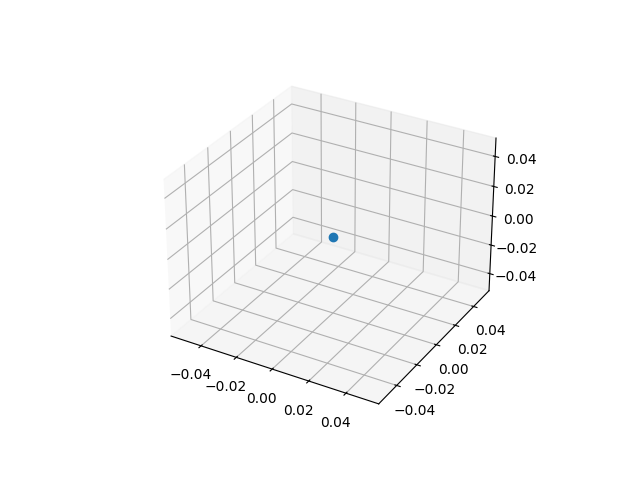

In [10]:
fig = plt.figure()
ax1 = fig.add_subplot(111, projection='3d')
traj1, = ax1.plot([0],[0], '-b', lw=2)
traj1.set_3d_properties([0])
pos1, = ax1.plot([0],[0], marker='o')# ax1.scatter(x1(0), y1(0), '+r')
pos1.set_3d_properties([0])


def animate(t_max):
    times = timespan[:int(t_max/dt)]
    traj1.set_data([r(t)[0] for t in times], [r(t)[1] for t in times])
    traj1.set_3d_properties ([r(t)[2] for t in times])
    pos1.set_data([r(t_max)[0]], [r(t_max)[1]] )
    pos1.set_3d_properties([r(t_max)[2]])
    
anim_running = True

def onClick(event):
    global anim_running
    if anim_running:
        ani.event_source.stop()
        anim_running = False
    else:
        ani.event_source.start()
        anim_running = True


def init():
    # 
    ax1.set_ylim(-30, 10)
    ax1.set_xlim(-10, 30)
    ax1.set_zlim(-1000, 40)
    # ax1.axhline(0, color='black', lw=1)
    # ax1.axvline(0, color='black', lw=1)
    # ax1.axiline(0, color='black', lw=1)
    plt.rcParams.update({'font.size': 10})

    return traj1, pos1


ani = FuncAnimation(fig, animate, timespan, init_func=init, interval=1, )
fig.canvas.mpl_connect('button_press_event', onClick)

plt.show()

In [11]:
phi

<function __main__.phi(t)>

In [12]:
rotation(np.array([1,1]) , 0)

array([-1.,  1.])